In [ ]:
#Use Slurm
import os
import sys
import gc
import time
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt

sys.path.append(
    "/projects/battobrah@xsede.org/software/anaconda/envs/geo_preproc/lib/python3.11/site-packages"
)

import geospatialtools.gdal_tools as gdal_tools

# ============================================================
# PATHS
# ============================================================

script_start = time.time()

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path, flush=True)

cid_list = range(1, 1601)
n_cids = len(cid_list)

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

print("=" * 70, flush=True)
print("Starting PP seasonal surface soil moisture mapping", flush=True)
print("Using individual CID GeoTIFFs, not full-domain VRTs", flush=True)
print(f"Number of CIDs: {n_cids}", flush=True)
print("=" * 70, flush=True)

# ============================================================
# READ TIME
# ============================================================

print("Reading time variable...", flush=True)

fp = nc.Dataset(path + "1/input_file.nc")
time_var = fp.groups["meteorology"]["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time_var, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

print("Finished reading time.", flush=True)
print(f"Number of time steps: {len(times)}", flush=True)
print(f"Start time: {times.iloc[0]}", flush=True)
print(f"End time: {times.iloc[-1]}", flush=True)

# ============================================================
# FUNCTION: READ TOP SMC
# ============================================================

def get_top_smc(ncfile):
    with nc.Dataset(ncfile) as ds:
        smc_var = ds.groups["data"].variables["smc"]
        dims = smc_var.dimensions
        smc = np.array(smc_var[:], dtype=np.float32)

    if "soil" in dims:
        soil_axis = dims.index("soil")
    elif "nsoil" in dims:
        soil_axis = dims.index("nsoil")
    elif "soil_layers" in dims:
        soil_axis = dims.index("soil_layers")
    else:
        soil_axis = int(np.argmin(smc.shape[1:]) + 1)

    if soil_axis == 2:
        data = smc[:, :, 0]
    elif soil_axis == 1:
        data = smc[:, 0, :]
    else:
        raise ValueError(f"Unexpected smc dimensions: {dims}, shape={smc.shape}")

    return data

# ============================================================
# FUNCTION: RECONSTRUCT ONE CID MAP
# ============================================================

def build_one_cid_map(cid, data_ave, path):
    hru_path = path + f"postprocess/hrus/{cid}.tif"

    hru = gdal_tools.read_raster(hru_path).astype(np.int32)
    meta = gdal_tools.retrieve_metadata(hru_path)

    cid_map = np.full(hru.shape, np.nan, dtype=np.float32)

    valid = hru != -9999
    hru_ids = hru[valid].astype(np.int32)

    # safety check
    good = (hru_ids >= 0) & (hru_ids < len(data_ave))

    vals = np.full(hru_ids.shape, np.nan, dtype=np.float32)
    vals[good] = data_ave[hru_ids[good]]

    cid_map[valid] = vals

    extent = [
        meta["minx"],
        meta["maxx"],
        meta["miny"],
        meta["maxy"],
    ]

    return cid_map, extent

# ============================================================
# FIRST PASS: COMPUTE GLOBAL MIN AND MAX
# ============================================================

global_min = np.inf
global_max = -np.inf

print("=" * 70, flush=True)
print("FIRST PASS: Computing global SMC min/max", flush=True)
print("=" * 70, flush=True)

t0_global = time.time()

for cid in cid_list:

    if cid % 50 == 0 or cid == n_cids:
        elapsed = (time.time() - t0_global) / 60
        print(
            f"First pass: CID {cid}/{n_cids} "
            f"({100 * cid / n_cids:.1f}%) "
            f"Elapsed: {elapsed:.1f} min",
            flush=True,
        )

    ncfile = path + f"output_data/{cid}/2014-01-01.nc"

    if not os.path.exists(ncfile):
        print(f"Missing file: {ncfile}", flush=True)
        continue

    try:
        data = get_top_smc(ncfile)

        for months in season_months:
            times_index = times.dt.month.isin(months).values
            data_ave = np.nanmean(data[times_index, :], axis=0)

            if np.any(np.isfinite(data_ave)):
                global_min = min(global_min, float(np.nanmin(data_ave)))
                global_max = max(global_max, float(np.nanmax(data_ave)))

        del data
        gc.collect()

    except Exception as e:
        print(f"ERROR in first pass for CID {cid}", flush=True)
        print(e, flush=True)
        continue

print("Finished first pass.", flush=True)
print(f"Global SMC min: {global_min}", flush=True)
print(f"Global SMC max: {global_max}", flush=True)

# ============================================================
# SECOND PASS: PLOT EACH SEASON USING INDIVIDUAL CID TILES
# ============================================================

print("=" * 70, flush=True)
print("SECOND PASS: Plotting seasonal maps from individual CID tiles", flush=True)
print("=" * 70, flush=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for iss, ax in enumerate(axes):

    my_season = seasons[iss]
    my_months = season_months[iss]
    times_index = times.dt.month.isin(my_months).values

    season_start = time.time()

    print("", flush=True)
    print("=" * 70, flush=True)
    print(f"Plotting {my_season}", flush=True)
    print("=" * 70, flush=True)

    last_im = None

    for cid in cid_list:

        if cid % 50 == 0 or cid == n_cids:
            elapsed = (time.time() - season_start) / 60
            print(
                f"{my_season}: CID {cid}/{n_cids} "
                f"({100 * cid / n_cids:.1f}%) "
                f"Elapsed: {elapsed:.1f} min",
                flush=True,
            )

        ncfile = path + f"output_data/{cid}/2014-01-01.nc"

        if not os.path.exists(ncfile):
            continue

        try:
            data = get_top_smc(ncfile)
            data_ave = np.nanmean(data[times_index, :], axis=0).astype(np.float32)

            cid_map, extent = build_one_cid_map(cid, data_ave, path)

            last_im = ax.imshow(
                cid_map,
                origin="lower",
                extent=extent,
                cmap="viridis",
                vmin=global_min,
                vmax=global_max,
                interpolation="nearest"
            )

            del data, data_ave, cid_map
            gc.collect()

        except Exception as e:
            print(f"ERROR while plotting CID {cid} for {my_season}", flush=True)
            print(e, flush=True)
            continue

    ax.set_title(f"PP Surface soil moisture (0–5 cm) - {my_season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    if last_im is not None:
        fig.colorbar(last_im, ax=ax, label="SMC [m³/m³]")

    print(f"Finished {my_season}", flush=True)
    print(f"{my_season} runtime: {(time.time() - season_start) / 60:.2f} min", flush=True)

print("Saving figure...", flush=True)

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "res_smc_surface_seasonal_PP_individual_cids_100hru.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.close()

print("=" * 70, flush=True)
print("All seasonal plots completed successfully.", flush=True)
print(f"Saved: {outfile}", flush=True)
print(f"Total runtime: {(time.time() - script_start) / 60:.2f} min", flush=True)
print("=" * 70, flush=True)

In [2]:
# 2016; winter only
import os
import sys
import time
import gc
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt

import geospatialtools.gdal_tools as gdal_tools

sys.path.append(
    "/projects/battobrah@xsede.org/software/anaconda/envs/geo_preproc/lib/python3.11/site-packages"
)

from dask import delayed, compute
from dask.distributed import Client


# ============================================================
# SETTINGS
# ============================================================

script_start = time.time()

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path, flush=True)

cid_list = list(range(1, 1601))

# Test only one season
season = "Winter"
season_months = (12, 1, 2)

# Test only one year
target_year = 2016

batch_size = 100
tile_buffer = 300

print("=" * 70, flush=True)
print("TEST: PP surface SMC, one season, one year", flush=True)
print(f"Season: {season}", flush=True)
print(f"Year: {target_year}", flush=True)
print(f"Tile buffer crop: {tile_buffer} pixels", flush=True)
print("=" * 70, flush=True)


# ============================================================
# READ TIME
# ============================================================

print("Reading time variable...", flush=True)

fp = nc.Dataset(path + "1/input_file.nc")
time_var = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time_var, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

# Only selected season and selected year
season_mask = (
    (times.dt.year == target_year) &
    (times.dt.month.isin(season_months))
).values

print("Finished reading time.", flush=True)
print(f"Total time steps: {len(times)}", flush=True)
print(f"Selected time steps for {season} {target_year}: {np.sum(season_mask)}", flush=True)


# ============================================================
# START DASK
# ============================================================

client = Client(
    n_workers=6,
    threads_per_worker=1,
    processes=True
)

print(client, flush=True)


# ============================================================
# DASK FUNCTION: READ ONE CID AND COMPUTE HRU MEAN
# ============================================================

@delayed
def process_one_cid(cid, path, season_mask):

    ncfile = path + f"output_data/{cid}/2014-01-01.nc"
    hru_file = path + f"postprocess/hrus/{cid}.tif"

    if not os.path.exists(ncfile):
        return cid, None, None, np.inf, -np.inf, f"Missing NetCDF: {ncfile}"

    if not os.path.exists(hru_file):
        return cid, None, None, np.inf, -np.inf, f"Missing HRU tif: {hru_file}"

    try:
        meta = gdal_tools.retrieve_metadata(hru_file)

        extent = [
            meta["minx"],
            meta["maxx"],
            meta["miny"],
            meta["maxy"],
        ]

        with nc.Dataset(ncfile) as fp:
            smc_top = np.array(
                fp.groups["data"].variables["smc"][:, :, 0],
                dtype=np.float32
            )

        data_ave = np.nanmean(
            smc_top[season_mask, :],
            axis=0
        ).astype(np.float32)

        cid_min = np.inf
        cid_max = -np.inf

        if np.any(np.isfinite(data_ave)):
            cid_min = float(np.nanmin(data_ave))
            cid_max = float(np.nanmax(data_ave))

        return cid, data_ave, extent, cid_min, cid_max, None

    except Exception as e:
        return cid, None, None, np.inf, -np.inf, str(e)


# ============================================================
# COMPUTE HRU MEANS
# ============================================================

results = []
global_min = np.inf
global_max = -np.inf

t0 = time.time()

for i in range(0, len(cid_list), batch_size):

    batch_cids = cid_list[i:i + batch_size]

    print(
        f"Processing CIDs {batch_cids[0]} to {batch_cids[-1]}",
        flush=True
    )

    tasks = [
        process_one_cid(cid, path, season_mask)
        for cid in batch_cids
    ]

    batch_results = compute(*tasks)

    for result in batch_results:

        cid, data_ave, extent, cid_min, cid_max, err = result

        if err is not None:
            print(f"CID {cid}: {err}", flush=True)
            continue

        results.append(result)

        global_min = min(global_min, cid_min)
        global_max = max(global_max, cid_max)

    print(
        f"Finished CIDs {batch_cids[0]} to {batch_cids[-1]} | "
        f"elapsed {(time.time() - t0) / 60:.2f} min",
        flush=True
    )

    del batch_results, tasks
    gc.collect()

print("Finished all CIDs.", flush=True)
print("Global SMC min:", global_min, flush=True)
print("Global SMC max:", global_max, flush=True)


# ============================================================
# FUNCTIONS
# ============================================================

def crop_tile(cid_map, extent, tile_buffer):

    if tile_buffer <= 0:
        return cid_map, extent

    ny, nx = cid_map.shape

    cropped = cid_map[
        tile_buffer:ny - tile_buffer,
        tile_buffer:nx - tile_buffer
    ]

    xmin, xmax, ymin, ymax = extent

    dx = (xmax - xmin) / nx
    dy = (ymax - ymin) / ny

    cropped_extent = [
        xmin + tile_buffer * dx,
        xmax - tile_buffer * dx,
        ymin + tile_buffer * dy,
        ymax - tile_buffer * dy,
    ]

    return cropped, cropped_extent


def reconstruct_cid_tile(cid, data_ave, path):

    hru_file = path + f"postprocess/hrus/{cid}.tif"

    hru = gdal_tools.read_raster(hru_file).astype(np.int32)

    cid_map = np.full(hru.shape, np.nan, dtype=np.float32)

    valid = hru != -9999
    hru_ids = hru[valid].astype(np.int32)

    good = (hru_ids >= 0) & (hru_ids < len(data_ave))

    vals = np.full(hru_ids.shape, np.nan, dtype=np.float32)
    vals[good] = data_ave[hru_ids[good]]

    cid_map[valid] = vals

    return cid_map


# ============================================================
# PLOT ONE SEASON, ONE YEAR
# ============================================================

print("=" * 70, flush=True)
print(f"Plotting {season} {target_year}", flush=True)

fig, ax = plt.subplots(figsize=(10, 7))

last_im = None

for k, result in enumerate(results):

    cid, data_ave, extent, cid_min, cid_max, err = result

    if data_ave is None:
        continue

    if (k + 1) % 100 == 0:
        print(f"  plotted {k + 1}/{len(results)} CIDs", flush=True)

    cid_map = reconstruct_cid_tile(
        cid,
        data_ave,
        path
    )

    cid_map, plot_extent = crop_tile(
        cid_map,
        extent,
        tile_buffer
    )

    last_im = ax.imshow(
        cid_map,
        origin="lower",
        extent=plot_extent,
        cmap="viridis",
        vmin=global_min,
        vmax=global_max,
        interpolation="nearest"
    )

    del cid_map
    gc.collect()

ax.set_title(f"PP Surface soil moisture (0–5 cm) – {season} {target_year}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

if last_im is not None:
    fig.colorbar(last_im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    f"test_smc_surface_PP_100hru_{season.lower()}_{target_year}_individual_cids_cropped.png"
)

fig.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved:", outfile, flush=True)

plt.close(fig)

client.shutdown()

print("=" * 70, flush=True)
print("All done.", flush=True)
print(f"Total runtime: {(time.time() - script_start) / 60:.2f} min", flush=True)
print("=" * 70, flush=True)

In [1]:
import netCDF4 as nc

file = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/postprocess/output_dir/20140101.nc"

fp = nc.Dataset(file)

lon = fp.variables["lon"][:]
lat = fp.variables["lat"][:]

print(f"Longitude: {lon[0]:.5f} to {lon[-1]:.5f}")
print(f"Latitude : {lat[0]:.5f} to {lat[-1]:.5f}")

fp.close()

Longitude: -114.23375 to -103.75042
Latitude : 33.75042 to 44.23375


In [1]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

cid_list = range(1, 1601)

winter_values = []
summer_values = []

# Create 3-hourly time axis
nt = 32120
start = pd.Timestamp("2014-01-01 00:00")
times = start + pd.to_timedelta(np.arange(nt) * 3, unit="h")
times = pd.Series(times)

winter = times.dt.month.isin([12, 1, 2]).values
summer = times.dt.month.isin([6, 7, 8]).values

print("Winter timesteps:", winter.sum())
print("Summer timesteps:", summer.sum())

for cid in cid_list:

    if cid % 50 == 0:
        print(f"Processing CID {cid}", flush=True)

    file = f"{path}output_data/{cid}/2014-01-01.nc"

    if not os.path.exists(file):
        continue

    fp = nc.Dataset(file)

    smc = fp.groups["data"].variables["smc"][:, :, 0]
    smc = np.where(smc < -9990, np.nan, smc)

    winter_values.append(np.nanmean(smc[winter, :]))
    summer_values.append(np.nanmean(smc[summer, :]))

    fp.close()

print()
print("===================================")
print(f"Winter basin mean SMC = {np.nanmean(winter_values):.6f}")
print(f"Summer basin mean SMC = {np.nanmean(summer_values):.6f}")
print("===================================")

Winter timesteps: 7920
Summer timesteps: 8096
Processing CID 50
Processing CID 100
Processing CID 150
Processing CID 200
Processing CID 250
Processing CID 300
Processing CID 350
Processing CID 400
Processing CID 450
Processing CID 500
Processing CID 550
Processing CID 600
Processing CID 650
Processing CID 700
Processing CID 750
Processing CID 800
Processing CID 850
Processing CID 900
Processing CID 950
Processing CID 1000
Processing CID 1050
Processing CID 1100
Processing CID 1150
Processing CID 1200
Processing CID 1250
Processing CID 1300
Processing CID 1350
Processing CID 1400
Processing CID 1450
Processing CID 1500
Processing CID 1550
Processing CID 1600

Winter basin mean SMC = 0.359213
Summer basin mean SMC = 0.119922


Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
Processing CID 50
Processing CID 100
Processing CID 150
Processing CID 200
Processing CID 250
Processing CID 300
Processing CID 350
Processing CID 400
Processing CID 450
Processing CID 500
Processing CID 550
Processing CID 600
Processing CID 650
Processing CID 700
Processing CID 750
Processing CID 800
Processing CID 850
Processing CID 900
Processing CID 950
Processing CID 1000
Processing CID 1050
Processing CID 1100
Processing CID 1150
Processing CID 1200
Processing CID 1250
Processing CID 1300
Processing CID 1350
Processing CID 1400
Processing CID 1450
Processing CID 1500
Processing CID 1550
Processing CID 1600
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/hor_n_HRU_mapped_100hru_full_domain.png


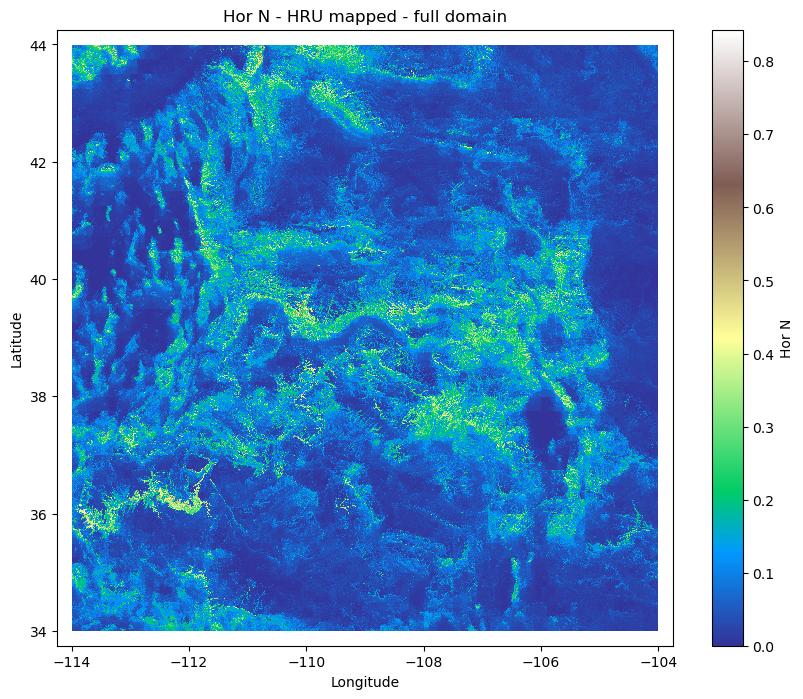

: 

In [2]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# paths

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

print("Simulation path:", path, flush=True)

# read hru and cid maps

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

hrus = gdal_tools.read_raster(hrus_file).astype(np.int32)
cids = gdal_tools.read_raster(cids_file).astype(np.int32)

metad = gdal_tools.retrieve_metadata(hrus_file)
extent = [metad["minx"], metad["maxx"], metad["miny"], metad["maxy"]]

# variable to plot

var = "hor_n"
cid_list = range(1, 1601)

# map hru values to raster

final_map = np.full(hrus.shape, -9999.0, dtype=np.float32)

for cid in cid_list:

    if cid % 50 == 0:
        print(f"Processing CID {cid}", flush=True)

    fp_path = path + f"{cid}/input_file.nc"

    if not os.path.exists(fp_path):
        print(f"Missing: {fp_path}", flush=True)
        continue

    with nc.Dataset(fp_path) as fp:
        grp = fp.groups["parameters"]

        if var not in grp.variables:
            print(f"{var} missing in CID {cid}", flush=True)
            continue

        data = np.array(grp.variables[var][:], dtype=np.float32)

    mask = (hrus != -9999) & (cids == cid)

    hru_ids = hrus[mask].astype(np.int32)
    valid = (hru_ids >= 0) & (hru_ids < len(data))

    rows, cols = np.where(mask)

    final_map[rows[valid], cols[valid]] = data[hru_ids[valid]]

final_map[final_map == -9999.0] = np.nan

# plot

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    final_map,
    origin="upper",
    extent=extent,
    cmap="terrain",
    interpolation="nearest"
)

ax.set_title("Hor N - HRU mapped - full domain")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.colorbar(im, ax=ax, label="Hor N")

outfile = os.path.join(outputdir, "hor_n_HRU_mapped_100hru_full_domain.png")
plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()

Number of seasonal time steps: 8085
Processing CID 459
Processing CID 460
Processing CID 461
Processing CID 499
Processing CID 500
Processing CID 501
Processing CID 539
Processing CID 540
Processing CID 541
Global min: 0.120982386
Global max: 0.47678402
Saved: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots/test_9cid_smc_spring_11yr_100hru_lonlat.png


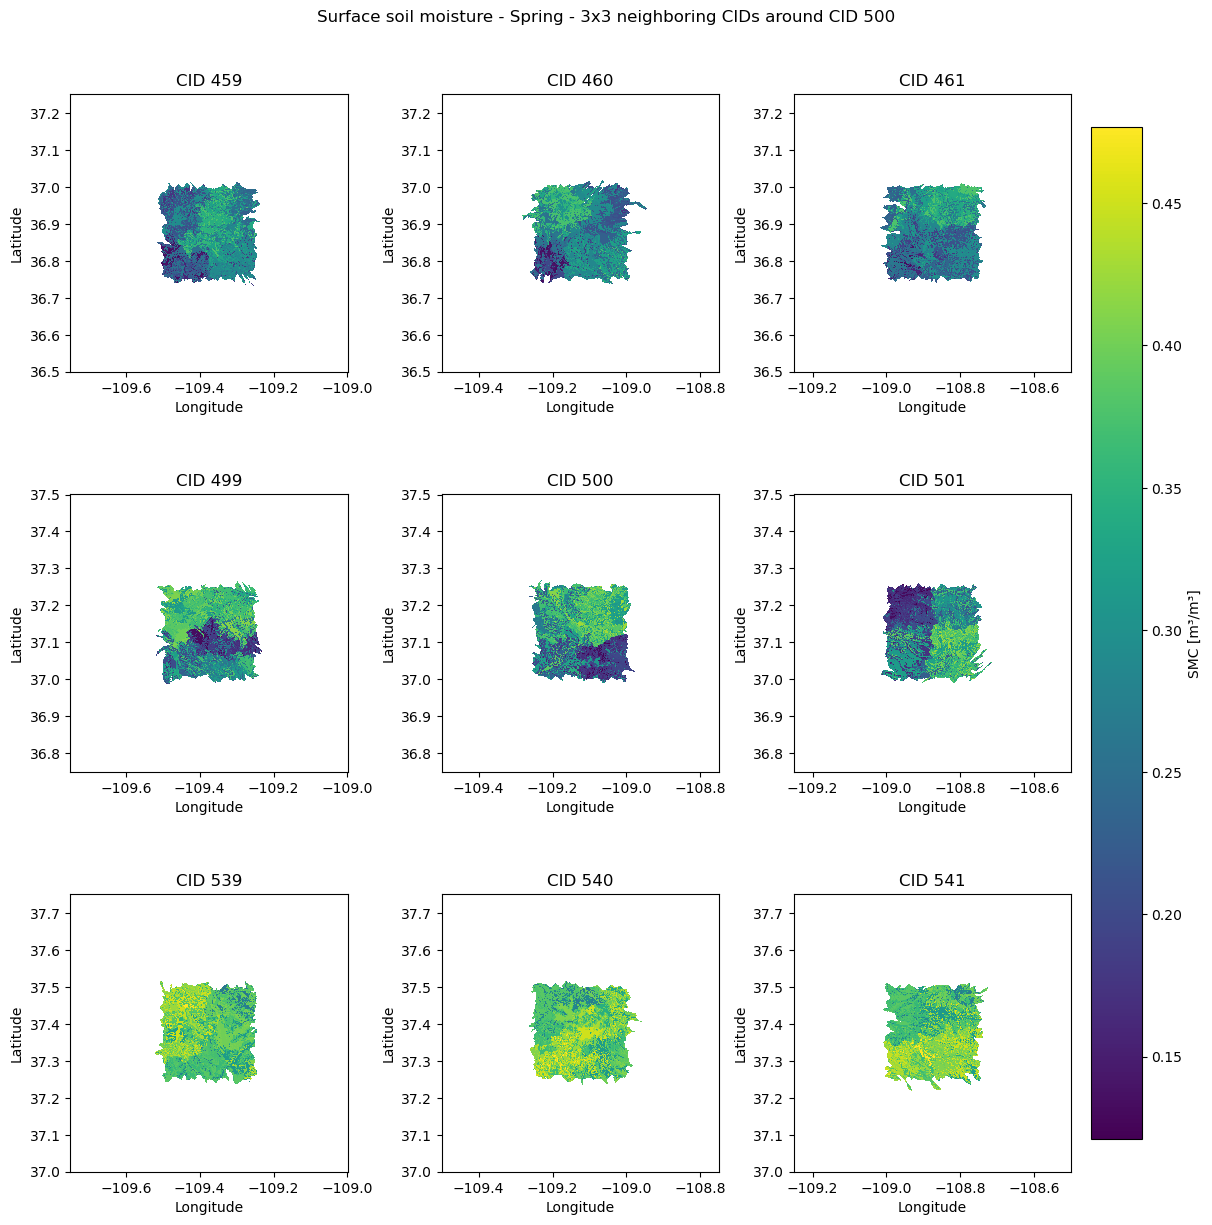

In [2]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# ============================================================
# PATHS
# ============================================================

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

# ============================================================
# CIDS TO PLOT
# 3 x 3 neighboring block around CID 500
# ============================================================

cid_list = [
    459, 460, 461,
    499, 500, 501,
    539, 540, 541
]

# ============================================================
# SEASON
# ============================================================

season = "Spring"
season_months = (3, 4, 5)

# ============================================================
# READ TIME
# ============================================================

fp = nc.Dataset(path + "1/input_file.nc")
time_var = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time_var, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")

times = pd.Series(datetime_series, name="datetime")
season_mask = times.dt.month.isin(season_months).values

print("Number of seasonal time steps:", season_mask.sum(), flush=True)

# ============================================================
# READ EACH CID AND COMPUTE SEASONAL SMC
# ============================================================

all_maps = []
all_extents = []

global_min = np.inf
global_max = -np.inf

for cid in cid_list:
    print(f"Processing CID {cid}", flush=True)

    hru_file = path + f"postprocess/hrus/{cid}.tif"
    nc_file = path + f"output_data/{cid}/2014-01-01.nc"

    if not os.path.exists(hru_file):
        print(f"Missing HRU file: {hru_file}", flush=True)
        continue

    if not os.path.exists(nc_file):
        print(f"Missing NetCDF file: {nc_file}", flush=True)
        continue

    hru = gdal_tools.read_raster(hru_file).astype(np.int32)
    meta = gdal_tools.retrieve_metadata(hru_file)

    fp = nc.Dataset(nc_file)
    smc = np.array(fp.groups["data"].variables["smc"][:, :, 0], dtype=np.float32)
    fp.close()

    data_ave = np.nanmean(smc[season_mask, :], axis=0).astype(np.float32)

    cid_map = np.full(hru.shape, np.nan, dtype=np.float32)

    valid = hru != -9999
    cid_map[valid] = data_ave[hru[valid].astype(np.int32)]

    extent = [
        meta["minx"],
        meta["maxx"],
        meta["miny"],
        meta["maxy"]
    ]

    all_maps.append(cid_map)
    all_extents.append(extent)

    global_min = min(global_min, np.nanmin(cid_map))
    global_max = max(global_max, np.nanmax(cid_map))

print("Global min:", global_min, flush=True)
print("Global max:", global_max, flush=True)

# ============================================================
# PLOT 3 x 3 FIGURE
# ============================================================

fig, axes = plt.subplots(
    3, 3,
    figsize=(12, 12),
    constrained_layout=True
)

for ax, cid, cid_map, extent in zip(axes.flat, cid_list, all_maps, all_extents):

    im = ax.imshow(
        cid_map,
        origin="lower",
        extent=extent,
        cmap="viridis",
        vmin=global_min,
        vmax=global_max,
        interpolation="nearest"
    )

    ax.set_title(f"CID {cid}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    label="SMC [m³/m³]",
    shrink=0.85,
    pad=0.02
)

fig.suptitle(
    f"Surface soil moisture - {season} - 3x3 neighboring CIDs around CID 500",
    y=1.02
)

outfile = os.path.join(
    outputdir,
    f"test_9cid_smc_{season.lower()}_11yr_100hru_lonlat.png"
)

plt.savefig(outfile, dpi=200, bbox_inches="tight")
print("Saved:", outfile, flush=True)

plt.show()

Saved: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots/stitched_9cid_smc_spring_11yr_100hru.png


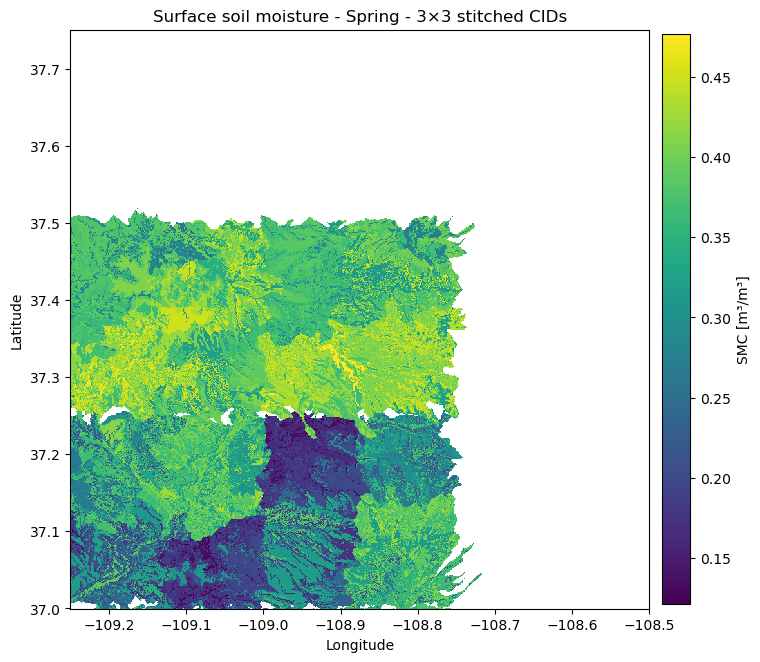

In [3]:
# ============================================================
# PLOT STITCHED 3x3 MOSAIC
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))

for cid_map, extent in zip(all_maps, all_extents):

    im = ax.imshow(
        cid_map,
        origin="lower",
        extent=extent,
        cmap="viridis",
        vmin=global_min,
        vmax=global_max,
        interpolation="nearest"
    )

ax.set_title(f"Surface soil moisture - {season} - 3×3 stitched CIDs")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.colorbar(
    im,
    ax=ax,
    label="SMC [m³/m³]",
    fraction=0.046,
    pad=0.02
)

ax.set_aspect("equal")

outfile = os.path.join(
    outputdir,
    f"stitched_9cid_smc_{season.lower()}_11yr_100hru.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

In [5]:
import os
import glob

files = glob.glob(path + "**/*.nc", recursive=True)

for f in files[:50]:
    print(f)

print("Total nc files:", len(files))

/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/705/input_file.nc
/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/338/input_file.nc
/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/1533/input_file.nc
/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/630/input_file.nc
/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/1347/input_file.nc
/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_1

In [1]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

cid_list = range(1, 51)

season_name = "Winter"
season_months = (12, 1, 2)

# ============================================================
# READ TIME
# ============================================================

time_file = path + "1/input_file.nc"

with nc.Dataset(time_file) as fp:
    time = fp.groups["meteorology"].variables["time"][:]

start = pd.Timestamp("2014-01-01 00:00:00")

times = pd.Series(
    start + pd.to_timedelta(time, unit="h"),
    name="datetime"
)

season_index = (
    (times.dt.year == 2014) &
    (times.dt.month.isin(season_months))
).values

print(f"{season_name} 2014 timesteps:", season_index.sum())
print()
print(f"{'CID':>5} {'MIN':>12} {'MEAN':>12} {'MAX':>12}")
print("-" * 45)

# ============================================================
# LOOP OVER CIDS
# ============================================================

for cid in cid_list:

    fp_path = path + f"output_data/{cid}/2014-01-01.nc"

    if not os.path.exists(fp_path):
        print(f"{cid:5d} Missing")
        continue

    with nc.Dataset(fp_path) as fp:

        # smc(time, hru, soil)
        smc = np.array(
            fp.groups["data"].variables["smc"][:, :, 0],
            dtype=np.float32
        )

    smc[smc <= -9990] = np.nan

    # mean over Winter 2014 time for each HRU
    hru_mean = np.nanmean(smc[season_index, :], axis=0)

    hru_mean = hru_mean[np.isfinite(hru_mean)]

    if len(hru_mean) == 0:
        print(f"{cid:5d} No valid data")
        continue

    print(
        f"{cid:5d}"
        f"{np.nanmin(hru_mean):12.6f}"
        f"{np.nanmean(hru_mean):12.6f}"
        f"{np.nanmax(hru_mean):12.6f}"
    )

Winter 2014 timesteps: 720

  CID          MIN         MEAN          MAX
---------------------------------------------
    1    0.120418    0.149986    0.198703
    2    0.120418    0.149986    0.198703
    3    0.120418    0.149986    0.198703
    4    0.120418    0.149986    0.198703
    5    0.120418    0.149986    0.198703
    6    0.120418    0.149986    0.198703
    7    0.120418    0.149986    0.198703
    8    0.120418    0.149986    0.198703
    9    0.120418    0.149986    0.198703
   10    0.120418    0.149986    0.198703
   11    0.120418    0.149986    0.198703
   12    0.120418    0.149986    0.198703
   13    0.120418    0.149986    0.198703
   14    0.105557    0.153378    0.216652
   15    0.105557    0.153378    0.216652
   16    0.105557    0.153378    0.216652
   17    0.105557    0.153378    0.216652
   18    0.105557    0.153378    0.216652
   19    0.105557    0.153378    0.216652
   20    0.105557    0.153378    0.216652
   21    0.105557    0.153378    0.216652

In [2]:
import netCDF4 as nc
import numpy as np

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"


for cid in [1, 2, 10, 50, 500]:

    fp_path = path + f"output_data/{cid}/2014-01-01.nc"

    with nc.Dataset(fp_path) as fp:
        smc = np.array(fp.groups["data"].variables["smc"][:, :, 0], dtype=np.float32)

    print(
        cid,
        "shape:", smc.shape,
        "first row first 5 HRUs:",
        smc[0, :5]
    )

1 shape: (32120, 100) first row first 5 HRUs: [0.29785156 0.29785156 0.29785156 0.29785156 0.29785156]
2 shape: (32120, 100) first row first 5 HRUs: [0.29785156 0.29785156 0.29785156 0.29785156 0.29785156]
10 shape: (32120, 100) first row first 5 HRUs: [0.29785156 0.29785156 0.29785156 0.29785156 0.29785156]
50 shape: (32120, 100) first row first 5 HRUs: [0.29785156 0.29785156 0.29785156 0.29785156 0.29785156]
500 shape: (32120, 100) first row first 5 HRUs: [0.29785156 0.29785156 0.29785156 0.29785156 0.29785156]


In [3]:
import netCDF4 as nc
import numpy as np

files = {}

for cid in [1, 2, 10, 50, 500]:

    fn = path + f"output_data/{cid}/2014-01-01.nc"

    with nc.Dataset(fn) as ds:
        files[cid] = np.array(
            ds.groups["data"].variables["smc"][:, :, 0],
            dtype=np.float32
        )

pairs = [(1,2), (1,10), (1,50), (1,500)]

for a, b in pairs:
    print(f"{a} vs {b}:", np.array_equal(files[a], files[b]))

1 vs 2: True
1 vs 10: True
1 vs 50: False
1 vs 500: False


In [4]:
import netCDF4 as nc
import numpy as np

reference = None

for cid in range(1, 51):

    fn = path + f"output_data/{cid}/2014-01-01.nc"

    with nc.Dataset(fn) as ds:
        smc = np.array(
            ds.groups["data"].variables["smc"][:, :, 0],
            dtype=np.float32
        )

    if reference is None:
        reference = smc
        print(f"{cid}: reference")
    else:
        same = np.array_equal(reference, smc)
        print(f"{cid:2d}: {same}")

1: reference
 2: True
 3: True
 4: True
 5: True
 6: True
 7: True
 8: True
 9: True
10: True
11: True
12: True
13: True
14: False
15: False
16: False
17: False
18: False
19: False
20: False
21: False
22: False
23: False
24: False


In [2]:
import os
import netCDF4 as nc

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

merged_file = path + "postprocess/output_dir/20140101.nc"

print("File exists:", os.path.exists(merged_file))
print("File:", merged_file)

with nc.Dataset(merged_file) as ds:
    print("\nDimensions:")
    for d in ds.dimensions:
        print(d, len(ds.dimensions[d]))

    print("\nRoot variables:")
    for v in ds.variables:
        print(v, ds.variables[v].shape)

    print("\nGroups:")
    for g in ds.groups:
        print("GROUP:", g)
        for v in ds.groups[g].variables:
            print("  ", v, ds.groups[g].variables[v].shape)

File exists: True
File: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/postprocess/output_dir/20140101.nc

Dimensions:
lon 630
lat 630
t 8

Root variables:
lon (630,)
lat (630,)
t (8,)
trad (8, 630, 630)
smc (8, 630, 630)
swe (8, 630, 630)
snowh (8, 630, 630)
fsno (8, 630, 630)

Groups:


Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/merged_postprocess_smc_20140101_dailymean.png


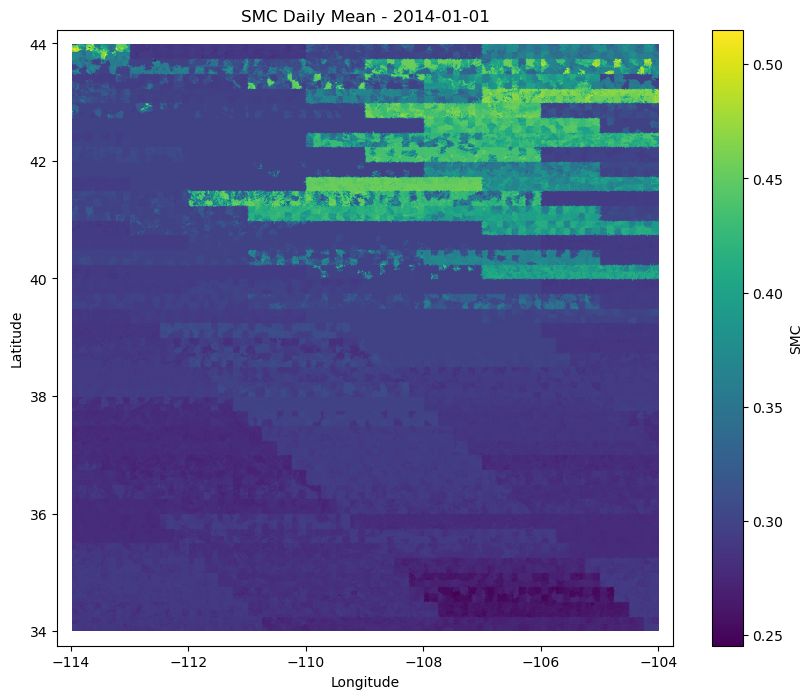

In [4]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

file = path + "postprocess/output_dir/20140101.nc"

with nc.Dataset(file) as ds:

    lon = ds.variables["lon"][:]
    lat = ds.variables["lat"][:]

    # Daily mean over the 8 three-hourly timesteps
    smc = np.nanmean(ds.variables["smc"][:], axis=0)

    smc[smc <= -9990] = np.nan

extent = [
    lon.min(),
    lon.max(),
    lat.min(),
    lat.max()
]

plt.figure(figsize=(10,8))

im = plt.imshow(
    smc,
    origin="lower",
    extent=extent,
    cmap="viridis",
    interpolation="nearest"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SMC Daily Mean - 2014-01-01")

plt.colorbar(im, label="SMC")

outfile = os.path.join(
    outputdir,
    "merged_postprocess_smc_20140101_dailymean.png"
)

plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

In [5]:
with nc.Dataset(path + "postprocess/output_dir/20140101.nc") as ds:
    lat = ds.variables["lat"][:]

print("Latitude spacing:")
print(np.diff(lat)[:10])
print("Unique spacings:", np.unique(np.round(np.diff(lat), 10)))

Latitude spacing:
[0.01666667 0.01666667 0.01666667 0.01666667 0.01666667 0.01666667
 0.01666667 0.01666667 0.01666667 0.01666667]
Unique spacings: [0.01666667]


In [6]:
import netCDF4 as nc
import numpy as np

with nc.Dataset(path + "postprocess/output_dir/20140101.nc") as ds:
    smc = np.nanmean(ds.variables["smc"][:], axis=0)

# Mean SMC for each latitude row
row_mean = np.nanmean(smc, axis=1)

print("First 20 row means:")
for i, v in enumerate(row_mean[:20]):
    print(f"{i:3d}: {v:.6f}")

First 20 row means:
  0: --
  1: --
  2: --
  3: --
  4: --
  5: --
  6: --
  7: --
  8: --
  9: --
 10: --
 11: --
 12: --
 13: --
 14: --
 15: 0.278781
 16: 0.278859
 17: 0.278763
 18: 0.278736
 19: 0.278676


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2497634/1748113002.py:12: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  print(f"{i:3d}: {v:.6f}")


In [ ]:
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import geospatialtools.gdal_tools as gdal_tools

# merged SMC
with nc.Dataset(path + "postprocess/output_dir/20140101.nc") as ds:
    smc = np.nanmean(ds.variables["smc"][:], axis=0)
    lon = ds.variables["lon"][:]
    lat = ds.variables["lat"][:]

smc = np.ma.filled(smc, np.nan)

# CID map
cid_map = gdal_tools.read_raster(path + "postprocess/cids.vrt")

extent = [lon.min(), lon.max(), lat.min(), lat.max()]

plt.figure(figsize=(10, 8))

plt.imshow(
    smc,
    origin="lower",
    extent=extent,
    cmap="viridis",
    interpolation="nearest"
)

# Draw CID boundaries
plt.contour(
    cid_map,
    levels=np.unique(cid_map),
    colors="k",
    linewidths=0.15,
    alpha=0.4,
    extent=extent
)

plt.title("Merged SMC with CID boundaries")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.colorbar(label="SMC")
plt.show()

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/merged_postprocess_smc_20140101_dailymean.png


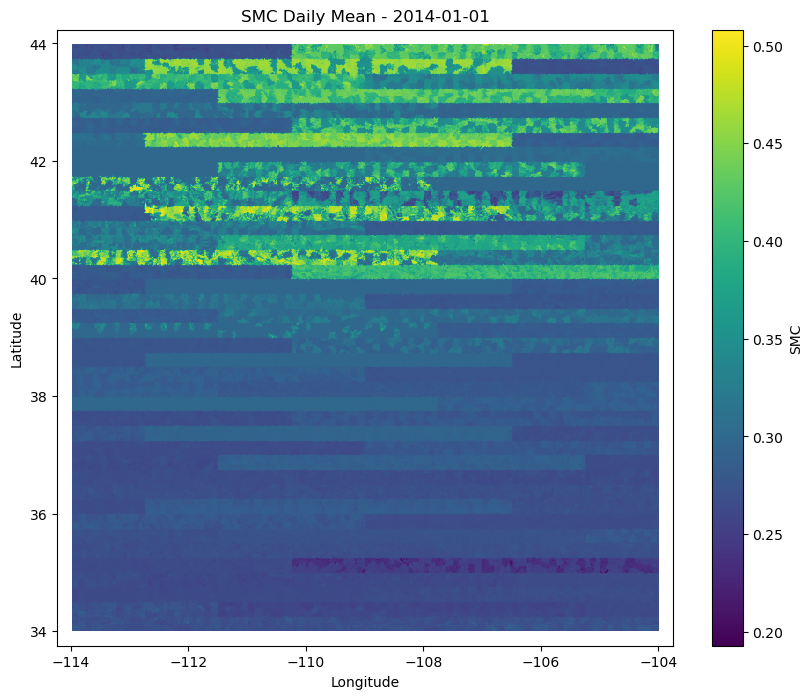

In [2]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_100hru_100bh_test_less_ranks/"

file = path + "postprocess/output_dir/20140101.nc"

with nc.Dataset(file) as ds:

    lon = ds.variables["lon"][:]
    lat = ds.variables["lat"][:]

    # Daily mean over the 8 three-hourly timesteps
    smc = np.nanmean(ds.variables["smc"][:], axis=0)

    smc[smc <= -9990] = np.nan

extent = [
    lon.min(),
    lon.max(),
    lat.min(),
    lat.max()
]

plt.figure(figsize=(10,8))

im = plt.imshow(
    smc,
    origin="lower",
    extent=extent,
    cmap="viridis",
    interpolation="nearest"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SMC Daily Mean - 2014-01-01")

plt.colorbar(im, label="SMC")

outfile = os.path.join(
    outputdir,
    "merged_postprocess_smc_20140101_dailymean.png"
)

plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

Processing CID 1
  Variable dimensions: ('time', 'hru', 'soil')
  Variable shape: (2896, 100, 10)
  Timesteps selected: 472
  Selected data shape: (472, 100)
  Number of HRU values: 100
  HRU value min/max: 0.109581895 0.2175624
  HRU raster shape: (901, 901)
  Valid raster pixels: 89510
  Wrote: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/winter2014_smc_cids_1_50_tiles/1.tif
Processing CID 2
  Variable dimensions: ('time', 'hru', 'soil')
  Variable shape: (2896, 100, 10)
  Timesteps selected: 472
  Selected data shape: (472, 100)
  Number of HRU values: 100
  HRU value min/max: 0.13546081 0.22402799
  HRU raster shape: (901, 901)
  Valid raster pixels: 91042
  Wrote: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/winter2014_smc_cids_1_50_tiles/2.tif
Processing CID 3
  Variable dimensions: ('time', 'hru', 'soil')
  Variable shape: (2896, 100, 10)
  Timesteps selected: 472
  Selected data shape: (472, 100)
  Number of HRU values: 100


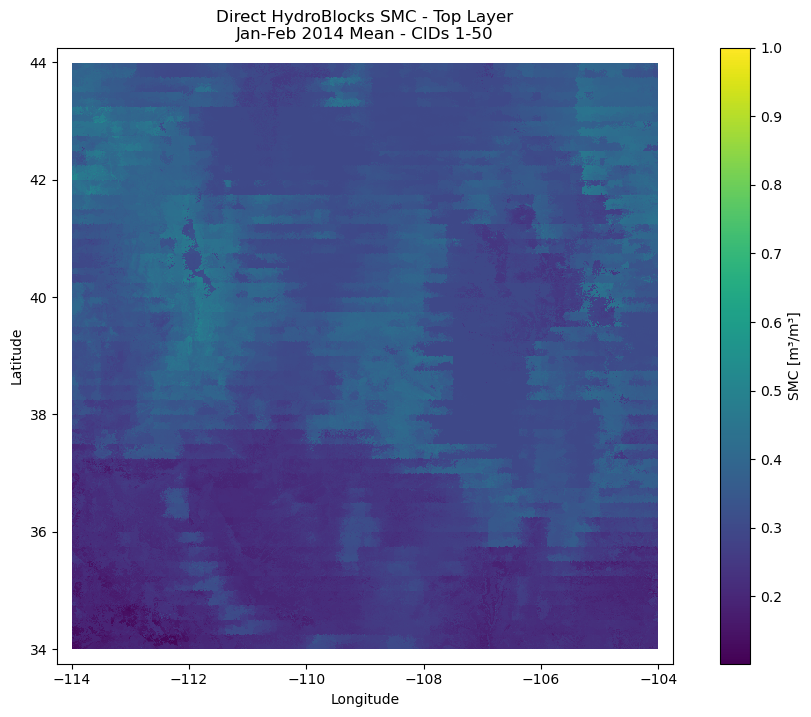

In [2]:
#!/usr/bin/env python3

import os
import subprocess
import numpy as np
import netCDF4 as nc
import rasterio
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

edir = (
    "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_100hru_100bh_bug_checking"
)

output_data = os.path.join(edir, "output_data")
hru_dir = os.path.join(edir, "postprocess", "hrus")

outputdir = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/output_plots"
)

os.makedirs(outputdir, exist_ok=True)


# ============================================================
# SETTINGS
# ============================================================

var = "smc"

# Top soil layer
layer = 0

# Direct HydroBlocks output file
stem = "2014-01-01"

# Time window
start_date = "2014-01-01"
end_date = "2014-02-28"

# First few CIDs
cid_list = range(1, 1601)

# Aggregation
agg = "mean"


# ============================================================
# OUTPUT FILES
# ============================================================

tile_output_dir = os.path.join(
    outputdir,
    "winter2014_smc_cids_1_50_tiles"
)

os.makedirs(tile_output_dir, exist_ok=True)

vrt_file = os.path.join(
    outputdir,
    "winter2014_smc_cids_1_50.vrt"
)

merged_tif = os.path.join(
    outputdir,
    "winter2014_smc_cids_1_50.tif"
)

plot_file = os.path.join(
    outputdir,
    "winter2014_smc_cids_1_50.png"
)


# ============================================================
# FUNCTION: GET TIME INDICES
# ============================================================

def window_indices(fp, start, end):

    """
    Select timesteps using the HydroBlocks metadata/date variable.

    date is in hours since 1900-01-01.
    """

    import datetime as dt

    dvar = fp.groups["metadata"].variables["date"]

    hours = np.asarray(
        dvar[:],
        dtype=np.float64
    )

    epoch = dt.datetime(1900, 1, 1)

    t0 = (
        dt.datetime.strptime(start, "%Y-%m-%d") - epoch
    ).total_seconds() / 3600.0

    # Inclusive end date
    t1 = (
        dt.datetime.strptime(end, "%Y-%m-%d")
        + dt.timedelta(days=1)
        - epoch
    ).total_seconds() / 3600.0

    idx = np.where(
        (hours >= t0) &
        (hours < t1)
    )[0]

    return idx


# ============================================================
# FUNCTION: PROCESS ONE CID
# ============================================================

def render_one(cid):

    print("=" * 60)
    print(f"Processing CID {cid}", flush=True)

    # --------------------------------------------------------
    # Files
    # --------------------------------------------------------

    ncpath = os.path.join(
        output_data,
        str(cid),
        stem + ".nc"
    )

    hrupath = os.path.join(
        hru_dir,
        f"{cid}.tif"
    )

    if not os.path.exists(ncpath):

        print(
            f"  Missing model file: {ncpath}",
            flush=True
        )

        return None

    if not os.path.exists(hrupath):

        print(
            f"  Missing HRU raster: {hrupath}",
            flush=True
        )

        return None


    # --------------------------------------------------------
    # Read model output
    # --------------------------------------------------------

    fp = nc.Dataset(ncpath, "r")

    try:

        fp.set_auto_mask(False)

        idx = window_indices(
            fp,
            start_date,
            end_date
        )

        if idx.size == 0:

            print(
                f"  No timesteps between "
                f"{start_date} and {end_date}",
                flush=True
            )

            return None


        # ----------------------------------------------------
        # Read variable
        # ----------------------------------------------------

        v = fp.groups["data"].variables[var]

        print(
            "  Variable dimensions:",
            v.dimensions,
            flush=True
        )

        print(
            "  Variable shape:",
            v.shape,
            flush=True
        )


        # ----------------------------------------------------
        # Read selected time window
        # ----------------------------------------------------

        raw = v[
            idx[0]:idx[-1] + 1,
            ...
        ]

        sub = np.asarray(
            raw,
            dtype=np.float32
        )


        # ----------------------------------------------------
        # Make sure selected indices match
        # ----------------------------------------------------

        if idx.size != sub.shape[0]:

            sub = sub[
                idx - idx[0]
            ]


        # ----------------------------------------------------
        # Select soil layer
        # ----------------------------------------------------

        if layer is not None:

            if sub.ndim != 3:

                print(
                    f"  ERROR: {var} is {sub.ndim}-D "
                    f"but layer was requested",
                    flush=True
                )

                return None

            # smc(time, hru, soil)
            sub = sub[:, :, layer]

        elif sub.ndim != 2:

            print(
                f"  ERROR: {var} is {sub.ndim}-D. "
                f"A layer must be specified.",
                flush=True
            )

            return None


        nt_used = sub.shape[0]

        print(
            f"  Timesteps selected: {nt_used}",
            flush=True
        )

        print(
            "  Selected data shape:",
            sub.shape,
            flush=True
        )


    finally:

        fp.close()


    # --------------------------------------------------------
    # Aggregate over time
    # --------------------------------------------------------

    with np.errstate(
        invalid="ignore",
        divide="ignore"
    ):

        if agg == "mean":

            vals = np.nanmean(
                sub,
                axis=0
            )

        elif agg == "max":

            vals = np.nanmax(
                sub,
                axis=0
            )

        elif agg == "min":

            vals = np.nanmin(
                sub,
                axis=0
            )

        elif agg == "sum":

            vals = np.nansum(
                sub,
                axis=0
            )

        else:

            raise ValueError(
                f"Unknown aggregation: {agg}"
            )


    vals = np.asarray(
        vals,
        dtype=np.float32
    )


    print(
        "  Number of HRU values:",
        vals.size,
        flush=True
    )

    print(
        "  HRU value min/max:",
        np.nanmin(vals),
        np.nanmax(vals),
        flush=True
    )


    # ========================================================
    # READ THIS CID'S OWN HRU RASTER
    # ========================================================

    with rasterio.open(hrupath) as src:

        hru = np.ascontiguousarray(
            src.read(
                1,
                masked=False
            )
        )

        profile = src.profile.copy()


    print(
        "  HRU raster shape:",
        hru.shape,
        flush=True
    )


    nodata = profile.get("nodata")

    if nodata is None:

        nodata = -9999.0


    # ========================================================
    # MAP HRU VALUES DIRECTLY TO TILE
    # ========================================================

    ids = hru.astype(
        np.int64
    )

    valid = (
        (hru != nodata)
        &
        (ids >= 0)
        &
        (ids < vals.size)
    )


    print(
        "  Valid raster pixels:",
        np.sum(valid),
        flush=True
    )


    if not valid.any():

        print(
            f"  CID {cid}: no valid HRU pixels",
            flush=True
        )

        return None


    # --------------------------------------------------------
    # Output tile
    # --------------------------------------------------------

    out = np.full(
        hru.shape,
        -9999.0,
        dtype=np.float32
    )


    # Critical mapping:
    #
    # raster HRU ID -> model HRU value
    #
    out[valid] = vals[
        ids[valid]
    ]


    # ========================================================
    # WRITE THIS CID'S GEOTIFF
    # ========================================================

    profile.update(
        dtype="float32",
        count=1,
        nodata=-9999.0,
        compress="deflate",
        tiled=True
    )


    tile_path = os.path.join(
        tile_output_dir,
        f"{cid}.tif"
    )


    with rasterio.open(
        tile_path,
        "w",
        **profile
    ) as dst:

        dst.write(
            out,
            1
        )


    print(
        f"  Wrote: {tile_path}",
        flush=True
    )


    return {
        "cid": cid,
        "file": tile_path,
        "nt": nt_used,
        "min": float(np.nanmin(vals)),
        "max": float(np.nanmax(vals))
    }


# ============================================================
# PROCESS ALL SELECTED CIDS
# ============================================================

results = []

for cid in cid_list:

    result = render_one(cid)

    if result is not None:

        results.append(result)


# ============================================================
# SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("SUMMARY")
print("=" * 70)

print(
    "Requested CIDs:",
    len(list(cid_list))
)

print(
    "Successfully processed:",
    len(results)
)


if len(results) == 0:

    raise RuntimeError(
        "No CIDs were successfully processed."
    )


# ------------------------------------------------------------
# Check timestep count
# ------------------------------------------------------------

nt_seen = sorted(
    set(
        r["nt"]
        for r in results
    )
)


print(
    "Timesteps used per tile:",
    nt_seen
)


if len(nt_seen) > 1:

    print(
        "WARNING: timestep count is NOT uniform across tiles!"
    )


# ------------------------------------------------------------
# Value range
# ------------------------------------------------------------

global_min = min(
    r["min"]
    for r in results
)

global_max = max(
    r["max"]
    for r in results
)


print(
    "Value range across tiles:",
    global_min,
    "to",
    global_max
)


# ============================================================
# CREATE FILE LIST FOR GDAL
# ============================================================

list_file = os.path.join(
    tile_output_dir,
    "files.txt"
)


with open(
    list_file,
    "w"
) as fh:

    for result in sorted(
        results,
        key=lambda x: x["cid"]
    ):

        fh.write(
            result["file"] + "\n"
        )


# ============================================================
# BUILD VRT
# ============================================================

print("\nBuilding VRT...", flush=True)


subprocess.run(
    [
        "gdalbuildvrt",

        "-srcnodata",
        "-9999",

        "-vrtnodata",
        "-9999",

        "-input_file_list",
        list_file,

        vrt_file
    ],
    check=True
)


print(
    "Created VRT:",
    vrt_file,
    flush=True
)


# ============================================================
# CREATE MERGED GEOTIFF
# ============================================================

print(
    "\nCreating merged GeoTIFF...",
    flush=True
)


subprocess.run(
    [
        "gdal_translate",

        "-co",
        "COMPRESS=DEFLATE",

        "-co",
        "TILED=YES",

        "-co",
        "BIGTIFF=IF_SAFER",

        vrt_file,
        merged_tif
    ],
    check=True
)


print(
    "Created merged GeoTIFF:",
    merged_tif,
    flush=True
)


# ============================================================
# READ MERGED TIFF
# ============================================================

with rasterio.open(
    merged_tif
) as src:

    merged = src.read(
        1
    ).astype(
        np.float32
    )

    bounds = src.bounds


# Convert nodata to NaN only for plotting
merged[
    merged <= -9990
] = np.nan


print(
    "Merged raster shape:",
    merged.shape,
    flush=True
)

print(
    "Merged valid pixels:",
    np.sum(
        np.isfinite(
            merged
        )
    ),
    flush=True
)

print(
    "Merged min:",
    np.nanmin(
        merged
    ),
    flush=True
)

print(
    "Merged max:",
    np.nanmax(
        merged
    ),
    flush=True
)


# ============================================================
# PLOT
# ============================================================

extent = [
    bounds.left,
    bounds.right,
    bounds.bottom,
    bounds.top
]


fig, ax = plt.subplots(
    figsize=(12, 8)
)


im = ax.imshow(
    merged,
    origin="upper",
    extent=extent,
    cmap="viridis",
    interpolation="nearest"
)


ax.set_title(
    "Direct HydroBlocks SMC - Top Layer\n"
    "Jan-Feb 2014 Mean - CIDs 1-50"
)


ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)


cbar = plt.colorbar(
    im,
    ax=ax,
    label="SMC [m³/m³]"
)


plt.savefig(
    plot_file,
    dpi=300,
    bbox_inches="tight"
)


print(
    "Saved plot:",
    plot_file,
    flush=True
)


plt.show()